# Day 21 - Customer Order Descriptive Statistics

Day 20 SQL 미니 프로젝트에서 만든 고객 단위 데이터를 이용해
대표값, 산포도, 사분위수와 이상치를 분석한다.

## 분석 목적

전체 고객의 주문 수를 평균 하나로 설명할 수 있는지 확인한다.

평균, 중앙값, 표준편차, 사분위수와 분포를 함께 확인하고
관리 대상별 고객 주문 활동의 차이를 비교한다.

## 분석 질문

1. 전체 고객의 평균 주문 수와 중앙값은 얼마인가?
2. 가장 자주 나타나는 주문 횟수는 몇 건인가?
3. 고객 주문 수의 표준편차는 얼마인가?
4. 고객 주문 수의 가운데 50%는 어느 범위에 있는가?
5. IQR 기준 잠재적 이상치가 존재하는가?
6. 관리 대상별 평균과 변동성은 어떻게 다른가?
7. 전체 평균 주문 수를 모든 고객에게 동일하게 적용해도 되는가?

## 통계 해석 기준

- 평균: 모든 값을 사용한 전체적인 수준
- 중앙값: 값을 정렬했을 때 가운데 수준
- 최빈값: 가장 자주 나타난 값
- 분산: 평균에서 떨어진 거리의 제곱 평균
- 표준편차: 원래 단위로 해석할 수 있는 변동성
- Q1: 하위 25% 지점
- Q2: 중앙값
- Q3: 하위 75% 지점
- IQR: Q3 - Q1
- 잠재적 이상치: Q1 - 1.5 × IQR 미만 또는 Q3 + 1.5 × IQR 초과

In [1]:
# 라이브러리 불러오기
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 프로젝트 경로 설정
project_root = Path.cwd().parent

input_path = (
    project_root
    / "outputs"
    / "customer_order_mini_project.csv"
)

output_dir = project_root / "outputs"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("프로젝트 경로:", project_root)
print("입력 파일 경로:", input_path)
print("출력 경로:", output_dir)

프로젝트 경로: d:\Study\Projects\00_foundation_review
입력 파일 경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_mini_project.csv
출력 경로: d:\Study\Projects\00_foundation_review\outputs


In [3]:
# 입력 파일 확인
print(
    "입력 파일 존재 여부:",
    input_path.exists()
)

입력 파일 존재 여부: True


In [4]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(df.head())

   customer_id customer_name   region grade  total_order_count  \
0            1           Kim    Seoul   VIP                  9   
1            5           Han    Seoul   VIP                  8   
2            6          Jung    Busan  GOLD                  7   
3            9          Yoon  Daejeon   VIP                  6   
4           25           Bae  Incheon   VIP                  6   

   paid_order_count  cancelled_order_count  paid_rate first_order_date  \
0                 9                      0      100.0       2026-01-15   
1                 8                      0      100.0       2025-12-20   
2                 6                      1       85.7       2026-01-05   
3                 6                      0      100.0       2026-01-07   
4                 6                      0      100.0       2026-01-12   

  last_order_date data_reference_date  active_period_days  \
0      2026-07-30          2026-07-31               196.0   
1      2026-07-31          2026-07-3

In [5]:
# 데이터 크기 확인
print("행과 열 개수:", df.shape)

행과 열 개수: (30, 18)


In [6]:
# 자료형 확인
print(df.dtypes)

customer_id                   int64
customer_name                   str
region                          str
grade                           str
total_order_count             int64
paid_order_count              int64
cancelled_order_count         int64
paid_rate                   float64
first_order_date                str
last_order_date                 str
data_reference_date             str
active_period_days          float64
avg_days_between_orders     float64
recency_days                float64
avg_customer_order_count    float64
order_count_rank              int64
activity_status                 str
management_action               str
dtype: object


In [7]:
# 결측치 확인
print(df.isna().sum())

customer_id                 0
customer_name               0
region                      0
grade                       0
total_order_count           0
paid_order_count            0
cancelled_order_count       0
paid_rate                   0
first_order_date            5
last_order_date             5
data_reference_date         0
active_period_days          6
avg_days_between_orders     6
recency_days                5
avg_customer_order_count    0
order_count_rank            0
activity_status             0
management_action           0
dtype: int64


## 변수 유형

- customer_id: 고객을 구분하는 식별자
- region: 명목형 범주
- grade: 순서형 범주
- total_order_count: 이산형 수치
- paid_order_count: 이산형 수치
- cancelled_order_count: 이산형 수치
- paid_rate: 수치형 비율
- recency_days: 이산형 수치
- activity_status: 순서가 있는 범주
- management_action: 명목형 범주

customer_id는 숫자로 저장되어 있지만 크기나 양을 의미하지 않으므로 평균을 계산하지 않는다.

In [8]:
# 이상치가 평균에 미치는 영향 실습
purchase_amount = pd.Series(
    [20, 22, 23, 24, 111]
)

example_mean = purchase_amount.mean()
example_median = purchase_amount.median()

print("예제 평균:", example_mean)
print("예제 중앙값:", example_median)

예제 평균: 40.0
예제 중앙값: 23.0


In [9]:
# 모집단, 표본 분산 비교
population_variance = purchase_amount.var(
    ddof=0
)

sample_variance = purchase_amount.var(
    ddof=1
)

print("모집단 분산:", population_variance)
print("표본 분산:", sample_variance)

모집단 분산: 1262.0
표본 분산: 1577.5


In [10]:
# 모집단, 표본 표준편차 비교
population_std = purchase_amount.std(
    ddof=0
)

sample_std = purchase_amount.std(
    ddof=1
)

print(
    "모집단 표준편차:",
    population_std
)

print(
    "표본 표준편차:",
    sample_std
)

모집단 표준편차: 35.52463933666322
표본 표준편차: 39.717754216471


In [11]:
# 분석할 수치 열 선택
numeric_columns = [
    "total_order_count",
    "paid_order_count",
    "cancelled_order_count",
    "paid_rate",
    "active_period_days",
    "avg_days_between_orders",
    "recency_days"
]

print(numeric_columns)

['total_order_count', 'paid_order_count', 'cancelled_order_count', 'paid_rate', 'active_period_days', 'avg_days_between_orders', 'recency_days']


In [12]:
# describe() 확인
describe_result = df[
    numeric_columns
].describe()

print(describe_result)

       total_order_count  paid_order_count  cancelled_order_count   paid_rate  \
count          30.000000         30.000000              30.000000   30.000000   
mean            3.466667          2.866667               0.600000   68.023333   
std             2.374191          2.417370               1.069966   40.112795   
min             0.000000          0.000000               0.000000    0.000000   
25%             2.000000          1.000000               0.000000   27.075000   
50%             3.500000          2.500000               0.000000   92.850000   
75%             5.000000          4.000000               1.000000  100.000000   
max             9.000000          9.000000               4.000000  100.000000   

       active_period_days  avg_days_between_orders  recency_days  
count           24.000000                24.000000     25.000000  
mean           134.500000                45.375000     34.880000  
std             54.626001                13.202314     45.407709  
mi

In [14]:
# 전체 기술통계표 생성
summary_df = pd.DataFrame(
    {
        "count": df[numeric_columns].count(),
        "mean": df[numeric_columns].mean(),
        "median": df[numeric_columns].median(),
        "std": df[numeric_columns].std(),
        "variance": df[numeric_columns].var(),
        "min": df[numeric_columns].min(),
        "q1": df[numeric_columns].quantile(0.25),
        "q3": df[numeric_columns].quantile(0.75),
        "max": df[numeric_columns].max()
    }
)

summary_df["iqr"] = (
    summary_df["q3"]
    - summary_df["q1"]
)

summary_df = summary_df.reset_index()

summary_df = summary_df.rename(
    columns={
        "index": "variable"
    }
)

print(summary_df)

                  variable  count        mean  median        std     variance  \
0        total_order_count     30    3.466667    3.50   2.374191     5.636782   
1         paid_order_count     30    2.866667    2.50   2.417370     5.843678   
2    cancelled_order_count     30    0.600000    0.00   1.069966     1.144828   
3                paid_rate     30   68.023333   92.85  40.112795  1609.036333   
4       active_period_days     24  134.500000  132.00  54.626001  2984.000000   
5  avg_days_between_orders     24   45.375000   43.00  13.202314   174.301087   
6             recency_days     25   34.880000   13.00  45.407709  2061.860000   

    min      q1       q3    max     iqr  
0   0.0   2.000    5.000    9.0   3.000  
1   0.0   1.000    4.000    9.0   3.000  
2   0.0   0.000    1.000    4.0   1.000  
3   0.0  27.075  100.000  100.0  72.925  
4  36.0  92.000  180.000  223.0  88.000  
5  24.5  38.475   54.475   69.0  16.000  
6   0.0   5.000   46.000  166.0  41.000  


In [15]:
# 주문 수 대표값
order_count_mean = (
    df["total_order_count"].mean()
)

order_count_median = (
    df["total_order_count"].median()
)

order_count_mode = (
    df["total_order_count"]
    .mode()
    .tolist()
)

print("평균 주문 수:", order_count_mean)
print("중앙값:", order_count_median)
print("최빈값:", order_count_mode)

평균 주문 수: 3.466666666666667
중앙값: 3.5
최빈값: [4]


In [16]:
# 주문 수 분산과 표준편차
order_count_variance = (
    df["total_order_count"].var()
)

order_count_std = (
    df["total_order_count"].std()
)

print(
    "주문 수 분산:",
    order_count_variance
)

print(
    "주문 수 표준편차:",
    order_count_std
)

주문 수 분산: 5.636781609195402
주문 수 표준편차: 2.3741907272153604


In [17]:
# Q1, 중앙값, Q3, IQR
q1 = df[
    "total_order_count"
].quantile(0.25)

median = df[
    "total_order_count"
].quantile(0.50)

q3 = df[
    "total_order_count"
].quantile(0.75)

iqr = q3 - q1

print("Q1:", q1)
print("중앙값:", median)
print("Q3:", q3)
print("IQR:", iqr)

Q1: 2.0
중앙값: 3.5
Q3: 5.0
IQR: 3.0


In [18]:
# 이상치 경계 계산
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("이상치 하한:", lower_bound)
print("이상치 상한:", upper_bound)

이상치 하한: -2.5
이상치 상한: 9.5


In [19]:
# 잠재적 이상치 고객 조회
outlier_customers = df[
    (
        df["total_order_count"]
        < lower_bound
    )
    |
    (
        df["total_order_count"]
        > upper_bound
    )
]

outlier_customers = outlier_customers[
    [
        "customer_id",
        "customer_name",
        "region",
        "grade",
        "total_order_count",
        "management_action"
    ]
]

print(outlier_customers)

Empty DataFrame
Columns: [customer_id, customer_name, region, grade, total_order_count, management_action]
Index: []


In [20]:
# 주문 없는 고객 제외 후 평균 비교
order_customer_df = df[
    df["total_order_count"] > 0
]

all_customer_mean = (
    df["total_order_count"].mean()
)

order_customer_mean = (
    order_customer_df[
        "total_order_count"
    ].mean()
)

print(
    "전체 고객 평균:",
    all_customer_mean
)

print(
    "주문 고객 평균:",
    order_customer_mean
)

전체 고객 평균: 3.466666666666667
주문 고객 평균: 4.16


In [21]:
# 관리 대상별 기술 통계
management_summary = df.groupby(
    "management_action"
)["total_order_count"].agg(
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ]
)

management_summary = (
    management_summary.reset_index()
)

management_summary = management_summary.round(
    2
)

print(management_summary)

        management_action  count  mean  median   std  min  max
0    activation_candidate      5  0.00     0.0  0.00    0    0
1      general_management      7  2.29     2.0  0.76    1    3
2      order_issue_review      4  4.00     4.0  0.82    3    5
3  reengagement_candidate      5  3.60     4.0  1.14    2    5
4      retention_priority      9  6.00     6.0  1.73    4    9


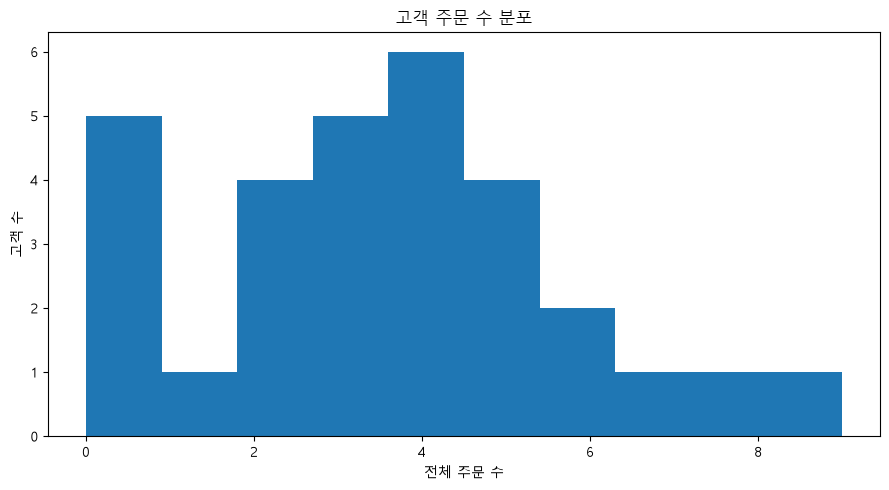

히스토그램 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_count_histogram.png


In [28]:
# 주문 수 히스토그램
from matplotlib import axes


df["total_order_count"].plot.hist(
    bins=10,
    figsize=(9, 5)
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.title("고객 주문 수 분포")
plt.xlabel("전체 주문 수")
plt.ylabel("고객 수")
plt.tight_layout()

histogram_path = (
    output_dir
    / "customer_order_count_histogram.png"
)

plt.savefig(
    histogram_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "히스토그램 저장 경로:",
    histogram_path
)

## 히스토그램 읽는 순서

1. 주문 수가 어느 구간에 많이 모여 있는지 확인한다.
2. 한쪽 방향으로 긴 꼬리가 있는지 확인한다.
3. 평균과 중앙값 차이와 연결해 본다.
4. 주문이 없는 고객과 주문이 많은 고객의 비중을 확인한다.

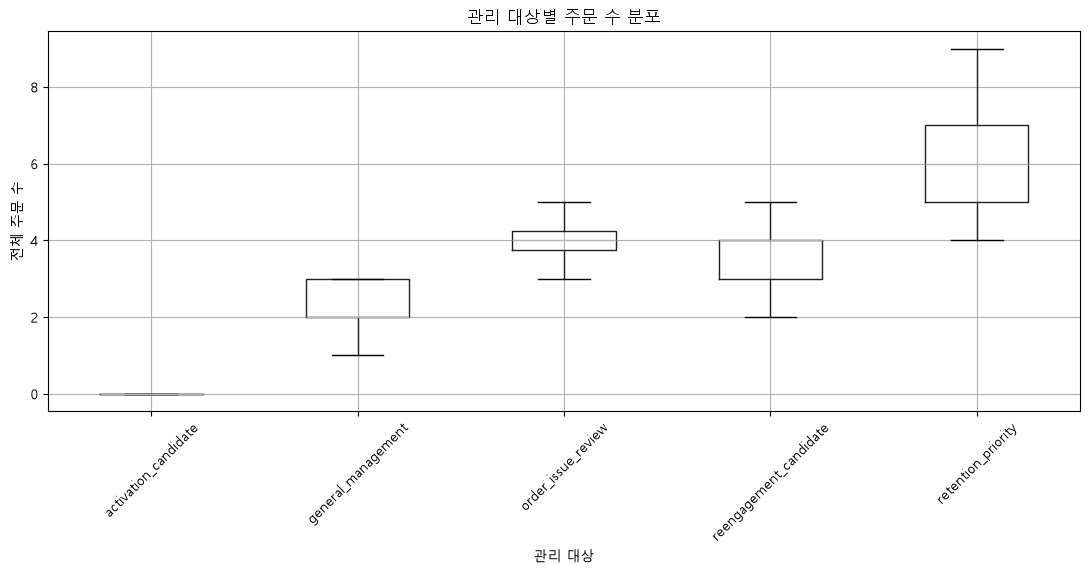

상자그림 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_count_boxplot.png


In [29]:
# 관리 대상별 주순 수 상자그림
df.boxplot(
    column="total_order_count",
    by="management_action",
    figsize=(11, 6),
    rot=45
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.title("관리 대상별 주문 수 분포")
plt.suptitle("")
plt.xlabel("관리 대상")
plt.ylabel("전체 주문 수")
plt.tight_layout()

boxplot_path = (
    output_dir
    / "customer_order_count_boxplot.png"
)

plt.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "상자그림 저장 경로:",
    boxplot_path
)

## 상자그림 읽는 순서

1. 상자 안의 중앙값 위치를 확인한다.
2. 상자의 길이인 IQR을 확인한다.
3. 위아래 수염 길이를 비교한다.
4. 수염 밖의 잠재적 이상치를 확인한다.
5. 고객군 사이 상자가 얼마나 겹치는지 확인한다.

In [30]:
# 전체 기술통계 CSV 저장
summary_path = (
    output_dir
    / "customer_order_descriptive_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "전체 기술통계 저장 경로:",
    summary_path
)

전체 기술통계 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_descriptive_summary.csv


In [31]:
# 관리 대상별 기술통계 CSV 저장
management_summary_path = (
    output_dir
    / "customer_management_descriptive_summary.csv"
)

management_summary.to_csv(
    management_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "관리 대상별 기술통계 저장 경로:",
    management_summary_path
)

관리 대상별 기술통계 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_management_descriptive_summary.csv


In [32]:
# 저장 결과 확인
saved_summary = pd.read_csv(
    summary_path
)

saved_management_summary = pd.read_csv(
    management_summary_path
)

print(saved_summary)
print(saved_management_summary)

print(
    "전체 기술통계 CSV:",
    summary_path.exists()
)

print(
    "관리 대상별 기술통계 CSV:",
    management_summary_path.exists()
)

print(
    "히스토그램:",
    histogram_path.exists()
)

print(
    "상자그림:",
    boxplot_path.exists()
)

                  variable  count        mean  median        std     variance  \
0        total_order_count     30    3.466667    3.50   2.374191     5.636782   
1         paid_order_count     30    2.866667    2.50   2.417370     5.843678   
2    cancelled_order_count     30    0.600000    0.00   1.069966     1.144828   
3                paid_rate     30   68.023333   92.85  40.112795  1609.036333   
4       active_period_days     24  134.500000  132.00  54.626001  2984.000000   
5  avg_days_between_orders     24   45.375000   43.00  13.202314   174.301087   
6             recency_days     25   34.880000   13.00  45.407709  2061.860000   

    min      q1       q3    max     iqr  
0   0.0   2.000    5.000    9.0   3.000  
1   0.0   1.000    4.000    9.0   3.000  
2   0.0   0.000    1.000    4.0   1.000  
3   0.0  27.075  100.000  100.0  72.925  
4  36.0  92.000  180.000  223.0  88.000  
5  24.5  38.475   54.475   69.0  16.000  
6   0.0   5.000   46.000  166.0  41.000  
        managem

## 핵심 결과

- 전체 고객 30명의 평균 주문 수는 약 3.47건이다.
- 중앙값은 3.5건이고 최빈값은 4건이다.
- 평균과 중앙값이 거의 비슷해 특정 고주문 고객 한 명이 전체 평균을 크게 왜곡하지는 않았다.
- 주문 수의 표준편차는 약 2.37건으로 고객 간 주문 활동 차이가 존재한다.
- 전체 고객의 가운데 50%는 주문 수 2건에서 5건 사이에 있다.
- IQR 기준 잠재적 이상치는 확인되지 않았다.
- 잠재적 이상치가 없더라도 고객 주문 수는 0건에서 9건까지 분포하므로 모든 고객의 활동이 비슷하다는 뜻은 아니다.
- 전체 평균만 볼 때보다 관리 대상별로 나누면 고객 활동 수준의 차이가 더 명확하게 나타난다.

## 관리 대상별 해석

- `activation_candidate` 고객은 주문 수가 모두 0건으로 변동성이 없다.
- `general_management` 고객의 평균 주문 수는 약 2.29건이고 표준편차는 약 0.76건이다.
- `order_issue_review` 고객의 평균과 중앙값은 모두 4건이지만 주문 상태에서 취소 비중을 별도로 확인해야 한다.
- `reengagement_candidate` 고객은 평균 주문 수가 약 3.6건으로 과거 주문 경험이 있지만 최근 주문 공백이 길다.
- `retention_priority` 고객의 평균과 중앙값은 모두 6건이며 최대 주문 수는 9건이다.
- 유지 우선 고객 안에서도 표준편차가 약 1.73건이므로 모든 고객의 주문 활동이 동일하지는 않다.

## 업무 결론

전체 고객의 평균 주문 수와 중앙값이 비슷하므로
전체 주문 수 분포가 특정 극단값에 크게 좌우되지는 않았다.

하지만 고객 관리 대상별 평균 주문 수는 0건부터 6건까지 차이가 있고
각 집단의 표준편차도 다르다.

따라서 전체 평균 주문 수 하나를 모든 고객에게 동일한 관리 기준으로 적용하기보다,
주문 여부, 최근 주문 경과일, 주문 상태와 고객군별 분포를 함께 고려해야 한다.

## 분석 한계

1. 분석 데이터는 학습을 위해 생성한 가상 데이터다.
2. 고객 수가 30명으로 실제 업무 데이터를 대표하지 않는다.
3. 주문 금액과 상품 정보가 없어 주문 횟수만 분석했다.
4. 주문 수가 많다고 해서 고객 매출 기여도가 높다고 볼 수 없다.
5. IQR 기준을 벗어나지 않는 값도 업무상 중요한 고활동 고객일 수 있다.
6. 기술통계는 현재 데이터를 요약하지만 차이의 원인이나 인과관계를 증명하지 않는다.
7. 고객군별 차이가 우연인지 판단하려면 이후 추론통계가 필요하다.